In [2]:
#load the complete volume of the image.

import os
import numpy as np
import random
import nibabel as nib
import tensorflow as tf
from sklearn.utils import shuffle
from tensorflow.keras.utils import to_categorical
from matplotlib import pyplot as plt
from scipy.ndimage import zoom


# Load NIfTI file and convert to NumPy array
def load_nii(path, is_mask=False):
    nii = nib.load(path)
    arr = np.array(nii.get_fdata(), dtype=np.float32)  # Convert to float32
    if is_mask:
        arr = arr.astype(np.int32)  # Masks as integers
    return arr


# Data Generator
def imageLoader_full(root_dir, patient_list, batch_size):

    L = len(patient_list)
    indices = np.arange(L)

    while True:
        indices = shuffle(indices, random_state=None)

        batch_start = 0
        batch_end = batch_size

        while batch_start < L:
            limit = min(batch_end, L)
            batch_indices = indices[batch_start:limit]

            X_t1, X_t1ce, X_t2, X_flair, Y = [], [], [], [], []

            for i in batch_indices:
                patient_id = patient_list[i]
                patient_path = os.path.join(root_dir, patient_id)

                files_needed = [
                    f"{patient_id}-t1n.nii",
                    f"{patient_id}-t1c.nii",
                    f"{patient_id}-t2w.nii",
                    f"{patient_id}-t2f.nii",
                    f"{patient_id}-seg.nii"
                ]

                files_exist = all(os.path.exists(os.path.join(patient_path, f)) for f in files_needed)
                if not files_exist:
                    print(f"Skipping {patient_id} due to missing files.")
                    continue

                # Load and resize modalities
                t1 = load_nii(os.path.join(patient_path, f"{patient_id}-t1n.nii"))
                t1ce = load_nii(os.path.join(patient_path, f"{patient_id}-t1c.nii"))
                t2 = load_nii(os.path.join(patient_path, f"{patient_id}-t2w.nii"))
                flair =load_nii(os.path.join(patient_path, f"{patient_id}-t2f.nii"))
                mask = load_nii(os.path.join(patient_path, f"{patient_id}-seg.nii"), is_mask=True)

                # Append to batch
                X_t1.append(t1)
                X_t1ce.append(t1ce)
                X_t2.append(t2)
                X_flair.append(flair)
                Y.append(mask)

            if len(X_t1) == 0:
                batch_start += batch_size
                batch_end += batch_size
                continue

            # Convert lists to NumPy arrays explicitly
            X_t1 = np.array(X_t1, dtype=np.float32)
            X_t1ce = np.array(X_t1ce, dtype=np.float32)
            X_t2 = np.array(X_t2, dtype=np.float32)
            X_flair = np.array(X_flair, dtype=np.float32)
            Y = np.array(Y, dtype=np.int32)

            # Normalization
            X_t1 = (X_t1 - np.mean(X_t1)) / np.std(X_t1)
            X_t1ce = (X_t1ce - np.mean(X_t1ce)) / np.std(X_t1ce)
            X_t2 = (X_t2 - np.mean(X_t2)) / np.std(X_t2)
            X_flair = (X_flair - np.mean(X_flair)) / np.std(X_flair)

            # Stack modalities
            X = np.stack([X_t1, X_t1ce, X_t2, X_flair], axis=4)

            # One-hot encode masks (4 classes)
            Y[Y > 3] = 3
            Y = to_categorical(Y, num_classes=4)

            yield (X, Y)

            batch_start += batch_size
            batch_end += batch_size


# Paths & Dataset
root_dir_full = r"F:\Tumor Centered Cropped Data"
patient_list_full = sorted(os.listdir(root_dir_full))

batch_size_full = 1

train_img_full = imageLoader_full(
    root_dir=root_dir_full,
    patient_list=patient_list_full,
    batch_size=batch_size_full,
)


img_full, msk_full = train_img_full.__next__()
test_img_full = img_full[0]
test_mask_full = msk_full[0]

print("Image shape:", test_img_full.shape)
print("Mask shape:", test_mask_full.shape)


Image shape: (128, 128, 128, 4)
Mask shape: (128, 128, 128, 4)


In [23]:
import os
import random
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split


# Dataset root
root_dir = r"F:\Tumor Centered Cropped Data"  # your single root folder

# Get all patient folders
all_patients = sorted(os.listdir(root_dir))

# Split into train and validation (e.g., 80% train, 20% val)
train_patient_list, val_patient_list = train_test_split(
    all_patients, test_size=0.2, random_state=42
)


print(f"Total patients: {len(all_patients)}")
print(f"Training patients: {len(train_patient_list)}")
print(f"Validation patients: {len(val_patient_list)}")

batch_size = 20


# Data generators
train_img_datagen = imageLoader_full(
    root_dir=root_dir,
    patient_list=train_patient_list,
    batch_size = batch_size
)

val_img_datagen = imageLoader_full(
    root_dir=root_dir,
    patient_list=val_patient_list,
    batch_size = batch_size
)

# Verify training generator
img, msk = train_img_datagen.__next__()

img_num = random.randint(0, img.shape[0] - 1)
test_img = img[img_num]
test_mask = msk[img_num]

print("Image shape:", test_img.shape)
print("Mask shape:", test_mask.shape)


Total patients: 300
Training patients: 240
Validation patients: 60
Image shape: (128, 128, 128, 4)
Mask shape: (128, 128, 128, 4)


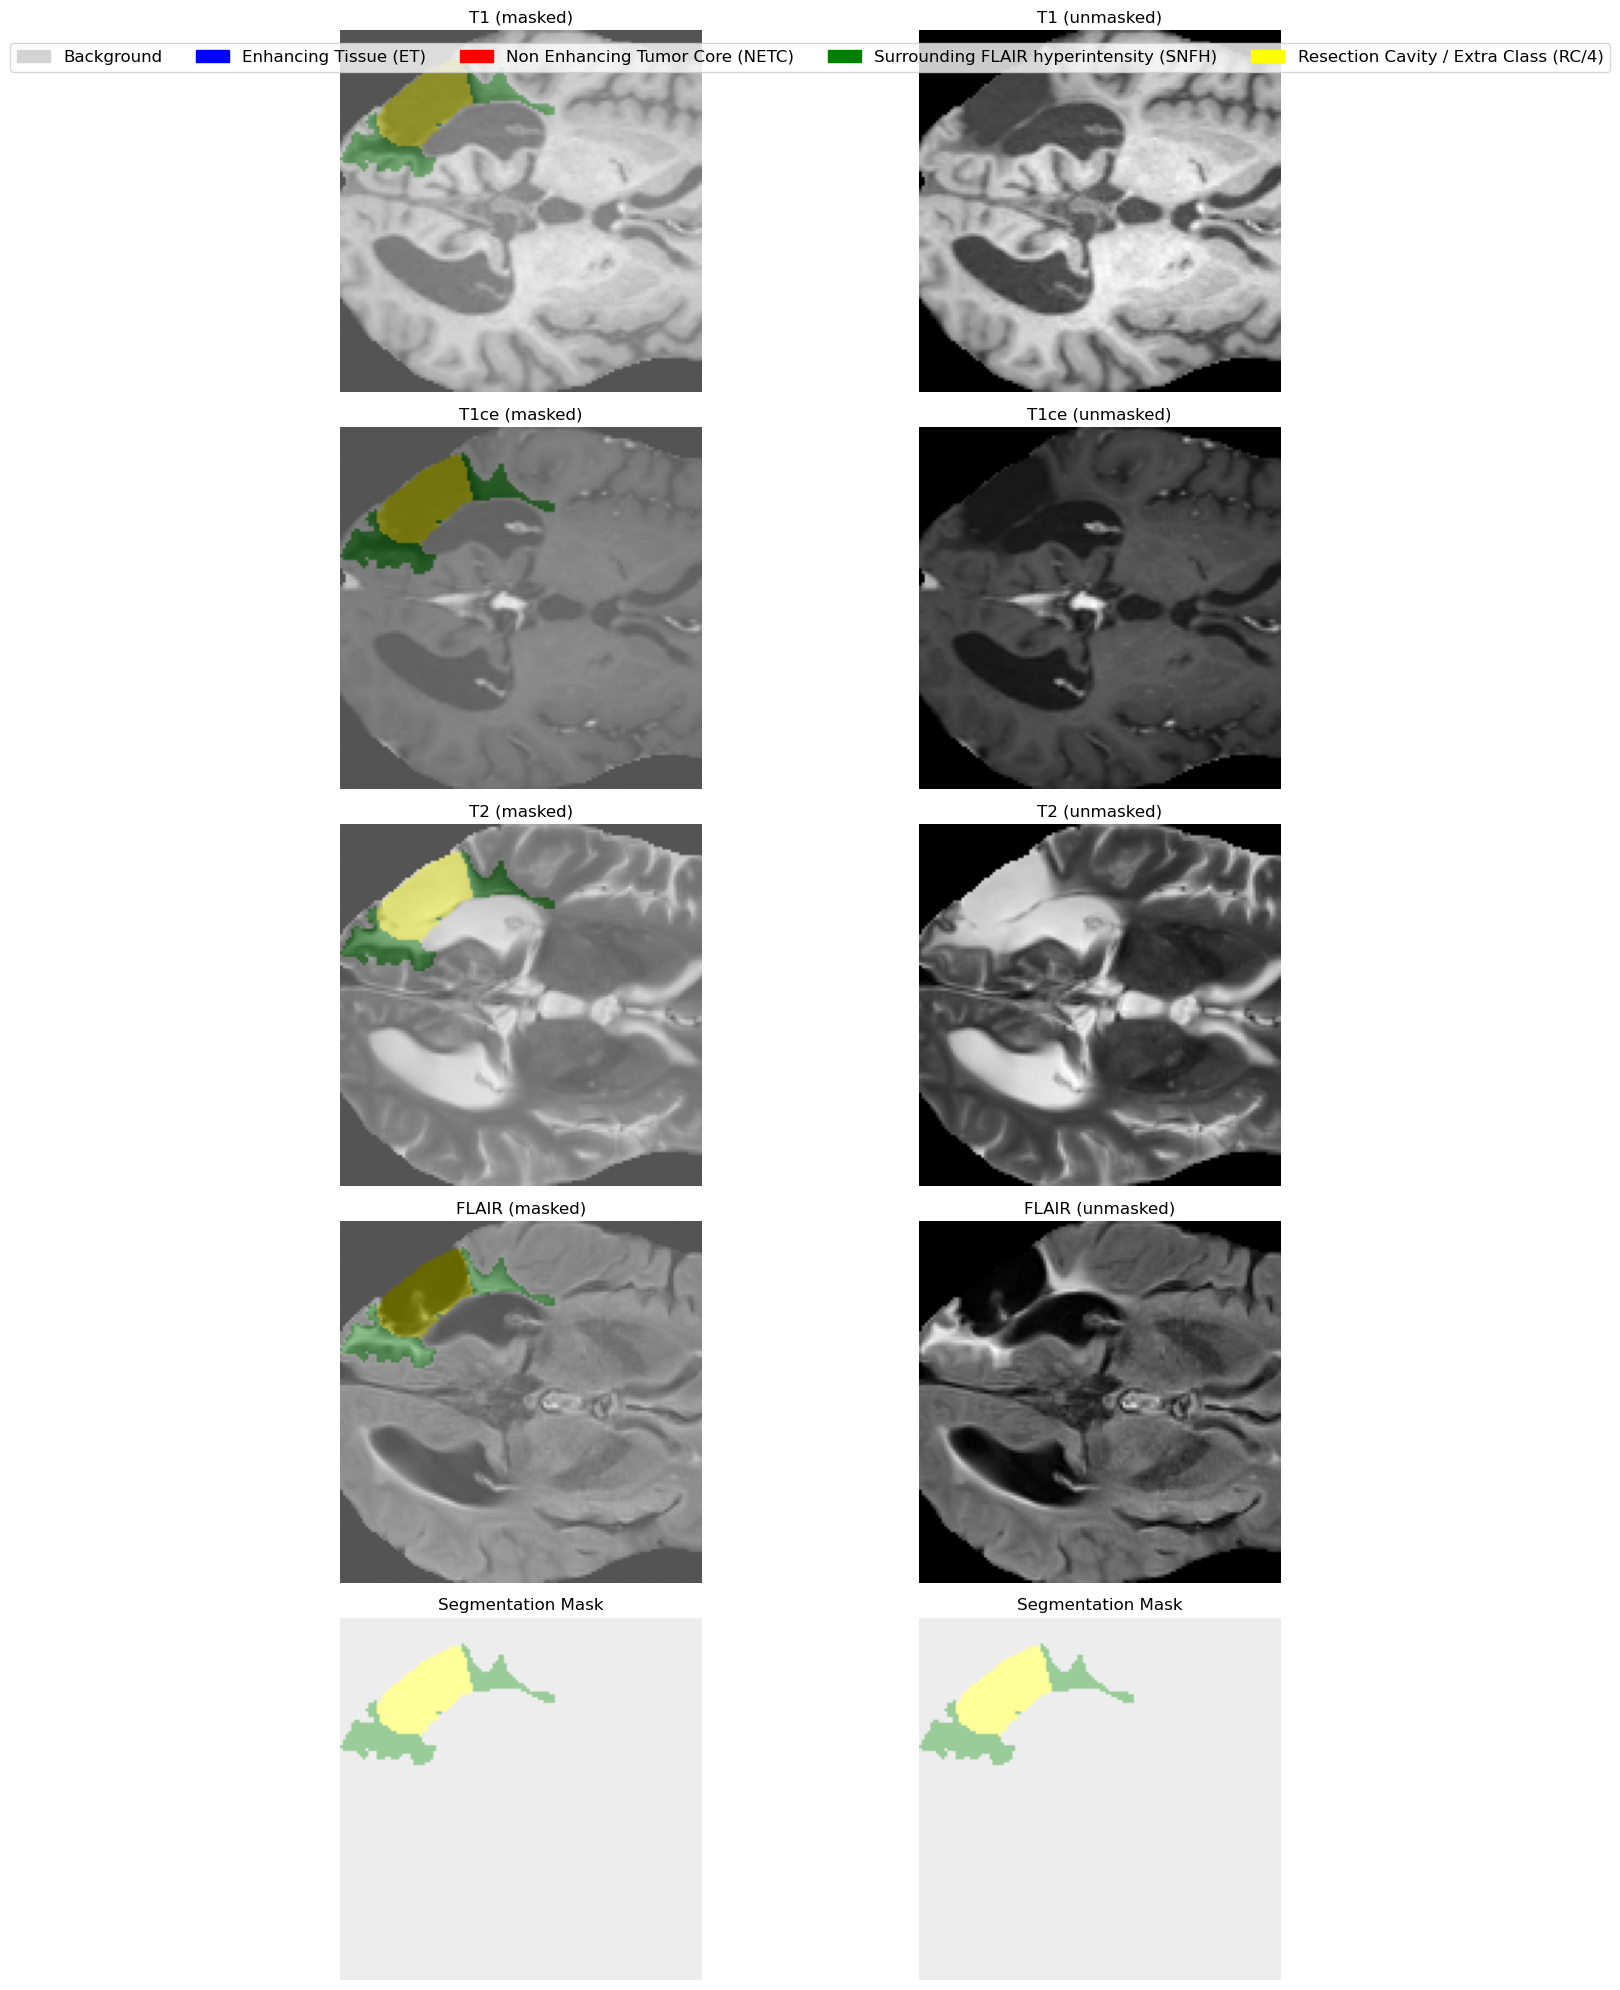

In [41]:
import random
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from matplotlib.patches import Patch

# Modalities
modalities = ['T1', 'T1ce', 'T2', 'FLAIR']

batch_img =16
# Select a patient from the batch
test_img = img[batch_img]
test_mask = msk[batch_img]

# Convert one-hot → labels
mask_slice = np.argmax(test_mask[:, :, 64, :], axis=-1)  # shape: H x W

# Define colors for 5 classes
colors_mask = ['lightgray', 'blue', 'red', 'green', 'yellow']  # 0=background
cmap_mask = matplotlib.colors.ListedColormap(colors_mask)

# Class names for 5 classes
class_names = [
    "Background",
    "Enhancing Tissue (ET)",
    "Non Enhancing Tumor Core (NETC)",
    "Surrounding FLAIR hyperintensity (SNFH)",
    "Resection Cavity / Extra Class (RC/4)"
]

# Create figure
fig, axs = plt.subplots(5, 2, figsize=(14, 20))  # 4 modalities + mask row, 2 columns

# Plot masked vs unmasked modalities
for i in range(4):
    # Masked
    axs[i, 0].imshow(test_img[:, :, 64, i], cmap='gray')
    axs[i, 0].imshow(mask_slice, cmap=cmap_mask, alpha=0.4)
    axs[i, 0].set_title(f"{modalities[i]} (masked)")
    axs[i, 0].axis('off')
    
    # Unmasked
    axs[i, 1].imshow(test_img[:, :, 64, i], cmap='gray')
    axs[i, 1].set_title(f"{modalities[i]} (unmasked)")
    axs[i, 1].axis('off')

# Mask alone (last row)
for j in range(2):
    axs[4, j].imshow(mask_slice, cmap=cmap_mask, alpha=0.4)
    axs[4, j].set_title("Segmentation Mask")
    axs[4, j].axis('off')

# Legend for classes
patches = [Patch(color=colors_mask[i], label=class_names[i]) for i in range(len(class_names))]
fig.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, 0.98), fontsize=12, ncol=5)

plt.tight_layout()
plt.show()
